# VLM Metrics (Snapshot-Based)

Run this notebook only while attached to the VLM Docker container (attached mode).

This notebook computes VLM annotation metrics with response normalization:
- yes/no -> 1/0
- number -> integer extracted from text

Metrics:
- binary fields: accuracy, precision, recall, F1
- numeric fields: MAE
- additional: valid response rate (correct format)

Ground-truth strategy:
1. Prefer nuImages object-annotation GT (if object mapping is available).
2. Fallback to reference snapshot GT (recommended: OpenAI snapshot) when direct nuImages mapping is unavailable.

For the current schema, quantitative field evaluation includes:
- numeric: `car_count`, `pedestrian_count`
- binary: `has_car` (derived), `has_pedestrian` (derived), `has_reconstruction_zone`


In [1]:
# Install dependencies (run once per environment)
!pip install -qU pandas scikit-learn matplotlib seaborn requests


In [1]:
from __future__ import annotations

import glob
import os
import json
import re
import tarfile

import requests
from collections import defaultdict
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error, precision_score, recall_score

# Configuration
# Resolve repo root for both launch modes:
# - from repository root
# - from notebooks/ directory
CWD = Path.cwd()
if (CWD / "data/nuimages").exists():
    REPO_ROOT = CWD
elif (CWD.parent / "data/nuimages").exists():
    REPO_ROOT = CWD.parent
else:
    REPO_ROOT = CWD

ROOT = str(REPO_ROOT / "data/nuimages")
META = f"{ROOT}/v1.0-train"
SNAPSHOT_GLOB = str(REPO_ROOT / "*vlm-snapshot*.tar.gz")
LIMIT_OBJECTS = None  # set int if needed

# GT mode options: "auto", "nuimages", "reference_snapshot"
GROUND_TRUTH_MODE = "auto"
REFERENCE_SNAPSHOT_LABEL = None  # e.g. "openai_snapshot_name"; None -> auto-detect

# Optional manual labels for snapshots
SNAPSHOT_LABELS: Dict[str, str] = {}

# Optional CSV to map storage object_id to nuImages sample token/path.
# Supported columns:
# - object_id + sd_token
# - object_id + filename
OBJECT_ID_MAPPING_CSV = None


# Optional online mapping fallback via Storage API (object_id -> key/storage_path)
STORAGE_API_LOOKUP_ENABLED = True
STORAGE_API_ENDPOINT = os.getenv("STORAGE_SERVER_ENDPOINT", "http://storage-server:9012").rstrip("/")
STORAGE_API_TIMEOUT_SEC = int(os.getenv("STORAGE_SERVER_TIMEOUT_SEC", "30"))
STORAGE_API_PAGE_SIZE = int(os.getenv("GT_STORAGE_PAGE_SIZE", "1000"))
STORAGE_API_MAX_PAGES = int(os.getenv("GT_STORAGE_MAX_PAGES", "0"))  # 0 = no limit

# Prevent self-evaluation leakage when GT is built from a reference snapshot
EXCLUDE_REFERENCE_GT_MODEL_FROM_SCORE = True

# Fields evaluated quantitatively
NUMERIC_FIELDS = ["car_count", "pedestrian_count"]
BINARY_FIELDS = ["has_car", "has_pedestrian", "has_reconstruction_zone"]

# Heuristic GT for reconstruction zone from nuImages object categories
RECONSTRUCTION_GT_CATEGORIES = {
    "vehicle.construction",
    "movable_object.trafficcone",
    "movable_object.barrier",
    "human.pedestrian.construction_worker",
}

FIELD_SCHEMA = {
    "car_count": {"type": "number"},
    "description": {"type": "text"},
    "driving_risk_level": {"type": "category", "allowed": {"low", "medium", "high", "critical", "unknown"}},
    "has_crosswalk": {"type": "yes_no"},
    "has_reconstruction_zone": {"type": "yes_no"},
    "lighting_condition": {"type": "category", "allowed": {"daylight", "dusk", "dawn", "night", "artificial_light", "low_light", "unknown"}},
    "main_risk_factor": {"type": "short_text"},
    "pedestrian_count": {"type": "number"},
    "pedestrian_crossing_road": {"type": "yes_no"},
    "scene_type": {"type": "category", "allowed": {"highway", "urban_street", "residential", "intersection", "parking_lot", "rural_road", "tunnel", "bridge", "roundabout", "unknown"}},
    "short_description": {"type": "short_text"},
    "traffic_light_state": {"type": "category", "allowed": {"red", "yellow", "green", "off", "not_visible", "unclear"}},
    "unexpected_object_on_road": {"type": "yes_no"},
    "weather_condition": {"type": "category", "allowed": {"clear", "cloudy", "rain", "snow", "fog", "wet_road", "unknown"}},
    "road_surface_condition": {"type": "category", "allowed": {"dry", "wet", "snowy", "icy", "muddy", "damaged", "unknown"}},
}

YES_SET = {"yes", "y", "true", "1"}
NO_SET = {"no", "n", "false", "0"}

sns.set_theme(style="whitegrid")


In [2]:
# NORMALIZATION + FORMAT VALIDATION
def normalize_yes_no(value) -> Tuple[Optional[int], bool]:
    if value is None:
        return None, False
    s = str(value).strip().lower()

    if s in YES_SET:
        return 1, True
    if s in NO_SET:
        return 0, True

    if re.search(r"\byes\b", s):
        return 1, True
    if re.search(r"\bno\b", s):
        return 0, True

    return None, False


def normalize_number(value) -> Tuple[Optional[int], bool]:
    if value is None:
        return None, False

    s = str(value).strip()
    match = re.search(r"-?\d+", s)
    if not match:
        return None, False

    num = int(match.group())
    if num < 0:
        return None, False
    return num, True


def normalize_category(value, allowed: set) -> Tuple[Optional[str], bool]:
    if value is None:
        return None, False

    s = str(value).strip().lower().replace(" ", "_")
    if s in allowed:
        return s, True
    return None, False


def normalize_short_text(value) -> Tuple[Optional[str], bool]:
    if value is None:
        return None, False

    s = str(value).strip()
    if not s:
        return None, False

    words = [w for w in re.split(r"\s+", s) if w]
    valid = 1 <= len(words) <= 12
    return s, bool(valid)


def normalize_text(value) -> Tuple[Optional[str], bool]:
    if value is None:
        return None, False

    s = str(value).strip()
    if not s:
        return None, False

    sentences = [x.strip() for x in re.split(r"[.!?]+", s) if x.strip()]
    valid = 3 <= len(sentences) <= 5
    return s, bool(valid)


def normalize_by_schema(field: str, value) -> Tuple[object, bool]:
    spec = FIELD_SCHEMA.get(field)
    if spec is None:
        s = "" if value is None else str(value).strip()
        return (s if s else None), bool(s)

    t = spec["type"]

    if t == "yes_no":
        return normalize_yes_no(value)
    if t == "number":
        return normalize_number(value)
    if t == "category":
        return normalize_category(value, spec["allowed"])
    if t == "short_text":
        return normalize_short_text(value)
    if t == "text":
        return normalize_text(value)

    s = "" if value is None else str(value).strip()
    return (s if s else None), bool(s)


In [3]:
# LOAD SNAPSHOTS
def _read_tar_member_text(tar: tarfile.TarFile, suffix: str, required: bool = True) -> Optional[str]:
    members = [m for m in tar.getmembers() if m.isfile() and m.name.endswith(suffix)]
    if not members:
        if required:
            raise FileNotFoundError(f"Member with suffix '{suffix}' not found in archive")
        return None

    with tar.extractfile(members[0]) as f:
        return f.read().decode("utf-8")


def _snapshot_label(path: str) -> str:
    if path in SNAPSHOT_LABELS:
        return SNAPSHOT_LABELS[path]
    return Path(path).stem


def _parse_ndjson(text: str) -> List[dict]:
    out = []
    for line in text.splitlines():
        line = line.strip()
        if not line:
            continue
        out.append(json.loads(line))
    return out


def load_snapshot_archive(path: str) -> dict:
    with tarfile.open(path, "r:gz") as tar:
        manifest_text = _read_tar_member_text(tar, "manifest.json", required=True)
        fields_text = _read_tar_member_text(tar, "fields.json", required=False)
        vlm_text = _read_tar_member_text(tar, "vlm.ndjson", required=False)
        objects_text = _read_tar_member_text(tar, "objects.ndjson", required=False)

    manifest = json.loads(manifest_text) if manifest_text else {}

    field_defs = {}
    if fields_text:
        fields = json.loads(fields_text)
        for item in fields:
            fn = str(item.get("field_name", "")).strip()
            rt = str(item.get("response_type", "")).strip().lower()
            if fn:
                field_defs[fn] = rt

    pred_df = pd.DataFrame(columns=["object_id"])
    if vlm_text:
        records = []
        for row in _parse_ndjson(vlm_text):
            object_id = str(row.get("object_id", "")).strip()
            values = row.get("values") or {}
            flat = {"object_id": object_id}
            if isinstance(values, dict):
                flat.update(values)
            records.append(flat)
        pred_df = pd.DataFrame(records)

    objects_df = pd.DataFrame(columns=["object_id", "storage_path", "bucket", "key", "object_file"])
    if objects_text:
        obj_records = []
        for row in _parse_ndjson(objects_text):
            obj_records.append(
                {
                    "object_id": str(row.get("object_id", "")).strip(),
                    "storage_path": str(row.get("storage_path", "")).strip(),
                    "bucket": str(row.get("bucket", "")).strip(),
                    "key": str(row.get("key", "")).strip(),
                    "object_file": str(row.get("object_file", "")).strip(),
                }
            )
        objects_df = pd.DataFrame(obj_records)

    return {
        "path": path,
        "label": _snapshot_label(path),
        "manifest": manifest,
        "field_defs": field_defs,
        "pred_df": pred_df,
        "objects_df": objects_df,
    }


snapshot_paths = sorted(glob.glob(SNAPSHOT_GLOB))
if not snapshot_paths:
    raise FileNotFoundError(f"No snapshots found by pattern: {SNAPSHOT_GLOB}")

snapshots = [load_snapshot_archive(p) for p in snapshot_paths]

print(f"Discovered snapshots: {len(snapshots)}")
for s in snapshots:
    print(
        f"- {s['label']}: "
        f"kind={s['manifest'].get('kind')}, "
        f"vlm_rows={len(s['pred_df'])}, "
        f"objects_rows={len(s['objects_df'])}, "
        f"created_at={s['manifest'].get('created_at')}"
    )


Discovered snapshots: 2
- vlm-snapshot_openai_11901.tar: kind=vlm, vlm_rows=11901, objects_rows=0, created_at=2026-05-13T01:48:16.716Z
- vlm-snapshot_smolvlm2B_551.tar: kind=vlm, vlm_rows=551, objects_rows=0, created_at=2026-05-13T01:44:54.916Z


In [4]:
# BUILD GROUND TRUTH (AUTO / NUIMAGES / REFERENCE SNAPSHOT)
def build_nuimages_counts_by_token() -> pd.DataFrame:
    object_ann = json.load(open(f"{META}/object_ann.json"))
    category_map = {c["token"]: c["name"] for c in json.load(open(f"{META}/category.json"))}

    counts = defaultdict(lambda: {"car_count": 0, "pedestrian_count": 0, "has_reconstruction_zone": 0})
    for ann in object_ann:
        sd_token = ann["sample_data_token"]
        cat = category_map[ann["category_token"]]
        if cat == "vehicle.car":
            counts[sd_token]["car_count"] += 1
        if cat.startswith("human.pedestrian."):
            counts[sd_token]["pedestrian_count"] += 1
        if cat in RECONSTRUCTION_GT_CATEGORIES:
            counts[sd_token]["has_reconstruction_zone"] = 1

    rows = []
    for sd_token, c in counts.items():
        car_count = int(c["car_count"])
        pedestrian_count = int(c["pedestrian_count"])
        rows.append(
            {
                "sd_token": sd_token,
                "car_count": car_count,
                "pedestrian_count": pedestrian_count,
                "has_car": int(car_count > 0),
                "has_pedestrian": int(pedestrian_count > 0),
                "has_reconstruction_zone": int(c["has_reconstruction_zone"]),
            }
        )

    return pd.DataFrame(rows)


def _normalize_candidate_filename(raw: str) -> str:
    s = str(raw or "").strip().strip('"').replace("\\", "/")
    if not s:
        return ""

    s = s.split("?", 1)[0].split("#", 1)[0].lstrip("/")
    for marker in ["sweeps/", "samples/"]:
        idx = s.find(marker)
        if idx >= 0:
            return s[idx:]
    return s


def build_nuimages_lookup_index() -> dict:
    sample_data = json.load(open(f"{META}/sample_data.json"))

    filename_to_token = {}
    basename_groups = defaultdict(set)
    tail2_groups = defaultdict(set)
    tail3_groups = defaultdict(set)

    for s in sample_data:
        token = str(s.get("token", "")).strip()
        fn = _normalize_candidate_filename(s.get("filename", ""))
        if not token or not fn:
            continue

        filename_to_token[fn] = token
        parts = Path(fn).parts
        if parts:
            basename_groups[parts[-1]].add(token)
        if len(parts) >= 2:
            tail2_groups["/".join(parts[-2:])].add(token)
        if len(parts) >= 3:
            tail3_groups["/".join(parts[-3:])].add(token)

    def _to_unique_map(groups):
        return {k: next(iter(v)) for k, v in groups.items() if len(v) == 1}

    return {
        "filename_to_token": filename_to_token,
        "basename_to_token": _to_unique_map(basename_groups),
        "tail2_to_token": _to_unique_map(tail2_groups),
        "tail3_to_token": _to_unique_map(tail3_groups),
    }


def _path_tail(value: str, depth: int) -> str:
    parts = Path(str(value or "")).parts
    if len(parts) < depth:
        return ""
    return "/".join(parts[-depth:])


def build_object_id_mapping_from_snapshot_objects(snapshots: list) -> pd.DataFrame:
    rows = []
    for snap in snapshots:
        obj = snap["objects_df"]
        if obj.empty:
            continue
        for _, r in obj.iterrows():
            object_id = str(r.get("object_id", "")).strip()
            if not object_id:
                continue
            candidate_sources = [r.get("key", ""), r.get("storage_path", ""), r.get("object_file", "")]
            for src in candidate_sources:
                cand = _normalize_candidate_filename(src)
                if cand:
                    rows.append({"object_id": object_id, "filename": cand})

    if not rows:
        return pd.DataFrame(columns=["object_id", "filename"])

    mapping = pd.DataFrame(rows).drop_duplicates(subset=["object_id", "filename"])
    return mapping


def build_object_id_mapping_from_storage_api(target_object_ids: set[str]) -> pd.DataFrame:
    if (not STORAGE_API_LOOKUP_ENABLED) or (not target_object_ids):
        return pd.DataFrame(columns=["object_id", "filename"])

    found_rows = []
    found_ids = set()
    cursor = None
    page = 0

    while True:
        if STORAGE_API_MAX_PAGES > 0 and page >= STORAGE_API_MAX_PAGES:
            break

        params = {"limit": max(1, STORAGE_API_PAGE_SIZE)}
        if cursor:
            params["cursor"] = cursor

        try:
            response = requests.get(
                f"{STORAGE_API_ENDPOINT}/objects",
                params=params,
                timeout=STORAGE_API_TIMEOUT_SEC,
            )
            response.raise_for_status()
            payload = response.json()
        except Exception as exc:
            print(f"[GT mapping] Storage API lookup failed on page {page + 1}: {exc}")
            break

        items = payload.get("items", [])
        if not isinstance(items, list):
            items = []

        for item in items:
            object_id = str(item.get("object_id", "")).strip()
            if not object_id or object_id not in target_object_ids:
                continue

            candidate_sources = [item.get("key", ""), item.get("storage_path", "")]
            for src in candidate_sources:
                cand = _normalize_candidate_filename(src)
                if cand:
                    found_rows.append({"object_id": object_id, "filename": cand})

            found_ids.add(object_id)

        page += 1
        if len(found_ids) >= len(target_object_ids):
            break

        cursor = payload.get("next_cursor") or payload.get("cursor")
        if not cursor:
            break

    if not found_rows:
        return pd.DataFrame(columns=["object_id", "filename"])

    mapped = pd.DataFrame(found_rows).drop_duplicates(subset=["object_id", "filename"])
    print(
        f"[GT mapping] Storage API mapped {mapped['object_id'].nunique()} / {len(target_object_ids)} object_ids "
        f"(endpoint={STORAGE_API_ENDPOINT}, pages={page})"
    )
    return mapped


def load_optional_external_mapping() -> pd.DataFrame:
    if not OBJECT_ID_MAPPING_CSV:
        return pd.DataFrame(columns=["object_id", "sd_token", "filename"])

    m = pd.read_csv(OBJECT_ID_MAPPING_CSV)
    cols = {c.lower(): c for c in m.columns}
    if "object_id" not in cols:
        raise ValueError("Mapping CSV must contain 'object_id' column")

    out = pd.DataFrame({"object_id": m[cols["object_id"]].astype(str).str.strip()})

    if "sd_token" in cols:
        out["sd_token"] = m[cols["sd_token"]].astype(str).str.strip()
    if "filename" in cols:
        out["filename"] = m[cols["filename"]].astype(str).str.strip()

    return out


def build_gt_from_nuimages_with_mapping(snapshots: list, nu_counts: pd.DataFrame, nu_index: dict) -> tuple[pd.DataFrame, str]:
    # 1) Direct overlap: object_id == sd_token
    all_object_ids = set()
    for snap in snapshots:
        if not snap["pred_df"].empty:
            all_object_ids.update(snap["pred_df"]["object_id"].astype(str).tolist())

    direct_ids = pd.DataFrame({"object_id": sorted(all_object_ids)})
    direct = direct_ids.rename(columns={"object_id": "sd_token"}).merge(nu_counts, on="sd_token", how="left")
    if not direct.empty and direct[["car_count", "pedestrian_count", "has_reconstruction_zone"]].notna().any(axis=None):
        direct[["car_count", "pedestrian_count", "has_car", "has_pedestrian", "has_reconstruction_zone"]] = (
            direct[["car_count", "pedestrian_count", "has_car", "has_pedestrian", "has_reconstruction_zone"]]
            .fillna(0)
            .astype(int)
        )
        direct = direct.rename(columns={"sd_token": "object_id"})
        return direct[["object_id", "car_count", "pedestrian_count", "has_car", "has_pedestrian", "has_reconstruction_zone"]], "nuImages direct object_id==sd_token"

    # 2) Build mapping object_id -> sd_token via filename
    ext_map = load_optional_external_mapping()
    snap_map = build_object_id_mapping_from_snapshot_objects(snapshots)

    # Optional online fallback: query storage API metadata by object_id
    known_ids = set()
    for df in [ext_map, snap_map]:
        if not df.empty and "object_id" in df.columns:
            known_ids.update(df["object_id"].astype(str).tolist())

    unresolved_ids = {oid for oid in all_object_ids if oid not in known_ids}
    storage_map = build_object_id_mapping_from_storage_api(unresolved_ids)

    mapping = pd.concat([ext_map, snap_map, storage_map], ignore_index=True, sort=False)
    if mapping.empty:
        return pd.DataFrame(columns=["object_id", "car_count", "pedestrian_count", "has_car", "has_pedestrian", "has_reconstruction_zone"]), "no mapping available (snapshot/csv/storage-api)"

    filename_to_token = nu_index["filename_to_token"]
    basename_to_token = nu_index["basename_to_token"]
    tail2_to_token = nu_index["tail2_to_token"]
    tail3_to_token = nu_index["tail3_to_token"]

    if "filename" in mapping.columns:
        mapping["filename_norm"] = mapping["filename"].map(_normalize_candidate_filename)
    else:
        mapping["filename_norm"] = ""

    if "sd_token" not in mapping.columns:
        mapping["sd_token"] = ""

    mapping["sd_token"] = mapping["sd_token"].astype(str)

    mask_missing = mapping["sd_token"].str.len() == 0
    mapping.loc[mask_missing, "sd_token"] = mapping.loc[mask_missing, "filename_norm"].map(filename_to_token).fillna("")

    mask_missing = mapping["sd_token"].str.len() == 0
    if mask_missing.any():
        base_keys = mapping.loc[mask_missing, "filename_norm"].map(lambda x: Path(str(x)).name)
        mapping.loc[mask_missing, "sd_token"] = base_keys.map(basename_to_token).fillna("")

    mask_missing = mapping["sd_token"].str.len() == 0
    if mask_missing.any():
        tail2_keys = mapping.loc[mask_missing, "filename_norm"].map(lambda x: _path_tail(x, 2))
        mapping.loc[mask_missing, "sd_token"] = tail2_keys.map(tail2_to_token).fillna("")

    mask_missing = mapping["sd_token"].str.len() == 0
    if mask_missing.any():
        tail3_keys = mapping.loc[mask_missing, "filename_norm"].map(lambda x: _path_tail(x, 3))
        mapping.loc[mask_missing, "sd_token"] = tail3_keys.map(tail3_to_token).fillna("")

    unresolved_after = mapping[mapping["sd_token"].str.len() == 0]
    if not unresolved_after.empty:
        sample_unresolved = unresolved_after["filename_norm"].dropna().astype(str)
        sample_unresolved = [x for x in sample_unresolved.tolist() if x][:5]
        if sample_unresolved:
            print(f"[GT mapping] unresolved filename examples: {sample_unresolved}")

    mapping = mapping[mapping["sd_token"].str.len() > 0][["object_id", "sd_token"]].drop_duplicates()
    if mapping.empty:
        return pd.DataFrame(columns=["object_id", "car_count", "pedestrian_count", "has_car", "has_pedestrian", "has_reconstruction_zone"]), "mapping exists but no sd_token matches"

    gt = mapping.merge(nu_counts, on="sd_token", how="left")
    for col in ["car_count", "pedestrian_count", "has_car", "has_pedestrian", "has_reconstruction_zone"]:
        gt[col] = gt[col].fillna(0).astype(int)

    gt = gt[["object_id", "car_count", "pedestrian_count", "has_car", "has_pedestrian", "has_reconstruction_zone"]].drop_duplicates("object_id")
    if gt.empty:
        return gt, "sd_token matched, but no nuImages rows after merge"

    return gt, f"nuImages via object_id mapping (snapshot/csv/storage-api), matched_rows={len(gt)}"


def select_reference_snapshot(snapshots: list) -> dict:
    if REFERENCE_SNAPSHOT_LABEL:
        for s in snapshots:
            if s["label"] == REFERENCE_SNAPSHOT_LABEL:
                return s
        raise ValueError(f"REFERENCE_SNAPSHOT_LABEL not found: {REFERENCE_SNAPSHOT_LABEL}")

    # Auto-priority: openai/gpt in label
    for s in snapshots:
        lbl = s["label"].lower()
        if "openai" in lbl or "gpt" in lbl:
            return s

    return snapshots[0]


def build_gt_from_reference_snapshot(snapshots: list) -> tuple[pd.DataFrame, str]:
    ref = select_reference_snapshot(snapshots)
    pred_df = ref["pred_df"].copy()

    rows = []
    for _, r in pred_df.iterrows():
        object_id = str(r.get("object_id", "")).strip()
        if not object_id:
            continue

        car_cnt, car_ok = normalize_number(r.get("car_count"))
        ped_cnt, ped_ok = normalize_number(r.get("pedestrian_count"))
        recon, recon_ok = normalize_yes_no(r.get("has_reconstruction_zone"))

        rows.append(
            {
                "object_id": object_id,
                "car_count": car_cnt if car_ok else np.nan,
                "pedestrian_count": ped_cnt if ped_ok else np.nan,
                "has_car": (int(car_cnt > 0) if car_ok else np.nan),
                "has_pedestrian": (int(ped_cnt > 0) if ped_ok else np.nan),
                "has_reconstruction_zone": (int(recon) if recon_ok else np.nan),
            }
        )

    gt = pd.DataFrame(rows).drop_duplicates("object_id")
    return gt, f"reference snapshot: {ref['label']}"


def resolve_ground_truth(snapshots: list) -> tuple[pd.DataFrame, str]:
    nu_counts = build_nuimages_counts_by_token()
    nu_index = build_nuimages_lookup_index()

    if GROUND_TRUTH_MODE == "nuimages":
        gt, reason = build_gt_from_nuimages_with_mapping(snapshots, nu_counts, nu_index)
        return gt, reason

    if GROUND_TRUTH_MODE == "reference_snapshot":
        gt, reason = build_gt_from_reference_snapshot(snapshots)
        return gt, reason

    # auto
    gt_nu, reason_nu = build_gt_from_nuimages_with_mapping(snapshots, nu_counts, nu_index)
    if len(gt_nu) > 0:
        return gt_nu, reason_nu

    gt_ref, reason_ref = build_gt_from_reference_snapshot(snapshots)
    return gt_ref, reason_ref + f" (auto fallback; nuImages failed: {reason_nu})"


gt_df, gt_reason = resolve_ground_truth(snapshots)
if LIMIT_OBJECTS is not None:
    gt_df = gt_df.head(int(LIMIT_OBJECTS)).copy()

print(f"GT mode used: {gt_reason}")
print(f"GT rows: {len(gt_df)}")
print(gt_df.head(3))


[GT mapping] Storage API mapped 11905 / 11905 object_ids (endpoint=http://storage-server:9012, pages=54)
GT mode used: nuImages via object_id mapping (snapshot/csv/storage-api), matched_rows=11905
GT rows: 11905
                          object_id  car_count  pedestrian_count  has_car  \
0  00008d0f8a5a96b8aacde9ce8e878c4f          0                 0        0   
1  0001694f21006fe2dae01853826b6017          0                 0        0   
2  0001a24406c091ea8dd52f985316e044          0                 0        0   

   has_pedestrian  has_reconstruction_zone  
0               0                        0  
1               0                        0  
2               0                        0  


In [5]:
# EVALUATION (GT METRICS + COMPLIANCE + CONSISTENCY + AGREEMENT)
from itertools import combinations

# Prevent leakage when GT is built from one of compared snapshots.
reference_model_label = None
_ref_match = re.search(r"reference snapshot:\s*([^()]+)", str(gt_reason))
if _ref_match:
    reference_model_label = _ref_match.group(1).strip()

reference_gt_active = "reference snapshot" in str(gt_reason).lower()
evaluation_snapshots = list(snapshots)
if reference_gt_active and EXCLUDE_REFERENCE_GT_MODEL_FROM_SCORE and reference_model_label:
    evaluation_snapshots = [s for s in snapshots if s.get("label") != reference_model_label]
    print(f"Excluding reference GT model from scoring: {reference_model_label}")
if not evaluation_snapshots:
    raise RuntimeError("No snapshots left for evaluation after reference-GT exclusion.")

# Evaluate schema compliance on the common field set present in all compared snapshots.
_common_sets = []
for _snap in evaluation_snapshots:
    _cols = set(_snap["pred_df"].columns) - {"object_id"}
    _common_sets.append(_cols)
COMMON_SNAPSHOT_FIELDS = sorted(set.intersection(*_common_sets)) if _common_sets else []
if not COMMON_SNAPSHOT_FIELDS:
    COMMON_SNAPSHOT_FIELDS = sorted(set(FIELD_SCHEMA.keys()))

REQUIRED_FIELDS = [f for f in FIELD_SCHEMA.keys() if f in COMMON_SNAPSHOT_FIELDS]
YES_NO_FIELDS = [f for f in ["has_crosswalk", "has_reconstruction_zone", "pedestrian_crossing_road", "unexpected_object_on_road"] if f in REQUIRED_FIELDS]
CATEGORY_FIELDS = [f for f in [
    "driving_risk_level",
    "lighting_condition",
    "scene_type",
    "traffic_light_state",
    "weather_condition",
    "road_surface_condition",
] if f in REQUIRED_FIELDS]
NUMBER_FIELDS = [f for f in ["car_count", "pedestrian_count"] if f in REQUIRED_FIELDS]
SHORT_TEXT_FIELDS = [f for f in ["main_risk_factor", "short_description"] if f in REQUIRED_FIELDS]
TEXT_FIELDS = [f for f in ["description"] if f in REQUIRED_FIELDS]


def strict_validate(field, raw_value):
    spec = FIELD_SCHEMA.get(field, {})
    t = spec.get("type", "")
    if raw_value is None:
        return False
    s = str(raw_value).strip()
    if not s:
        return False

    if t == "yes_no":
        return s in {"Yes", "No"}
    if t == "number":
        return bool(re.fullmatch(r"\d+", s))
    if t == "category":
        allowed = spec.get("allowed", set())
        return s in allowed
    if t == "short_text":
        words = [w for w in re.split(r"\s+", s) if w]
        return 1 <= len(words) <= 12
    if t == "text":
        sentences = [x.strip() for x in re.split(r"[.!?]+", s) if x.strip()]
        return 3 <= len(sentences) <= 5
    return True


def _merged_gt_value(row, field, pred_columns):
    gt_name = f"{field}_gt"
    if gt_name in row.index:
        return row[gt_name]
    # If no name collision during merge, GT column can stay as-is.
    if field in row.index and field not in pred_columns:
        return row[field]
    return np.nan


def _merged_pred_value(row, field):
    pred_name = f"{field}_pred"
    if pred_name in row.index:
        return row[pred_name]
    if field in row.index:
        return row[field]
    return None


def evaluate_snapshot(snapshot, gt_df):
    model_label = snapshot["label"]
    pred_df = snapshot["pred_df"].copy()

    if pred_df.empty:
        empty = pd.DataFrame()
        return empty, empty, empty, empty, empty

    pred_df["object_id"] = pred_df["object_id"].astype(str)
    pred_columns = set(pred_df.columns) - {"object_id"}

    # ---------- normalized rows for compliance/behavior/agreement ----------
    normalized_rows = []
    row_quality_rows = []
    consistency_rows = []

    for _, r in pred_df.iterrows():
        object_id = str(r.get("object_id", "")).strip()
        parsed_map = {}
        parsed_valid_map = {}

        missing_count = 0
        parsed_ok_count = 0
        strict_ok_count = 0

        for field in REQUIRED_FIELDS:
            raw = r.get(field, None)
            missing = raw is None or str(raw).strip() == ""
            if missing:
                missing_count += 1

            parsed_value, parsed_valid = normalize_by_schema(field, raw)
            strict_valid = strict_validate(field, raw)
            response_type = FIELD_SCHEMA[field]["type"]

            parsed_map[field] = parsed_value
            parsed_valid_map[field] = bool(parsed_valid)

            parsed_ok_count += int(bool(parsed_valid))
            strict_ok_count += int(bool(strict_valid))

            normalized_rows.append(
                {
                    "model": model_label,
                    "object_id": object_id,
                    "field": field,
                    "response_type": response_type,
                    "raw_value": raw,
                    "parsed_value": parsed_value,
                    "parsed_valid": bool(parsed_valid),
                    "strict_valid": bool(strict_valid),
                    "missing": bool(missing),
                }
            )

        row_quality_rows.append(
            {
                "model": model_label,
                "object_id": object_id,
                "required_fields": len(REQUIRED_FIELDS),
                "missing_fields": missing_count,
                "parsed_valid_ratio": parsed_ok_count / len(REQUIRED_FIELDS),
                "strict_valid_ratio": strict_ok_count / len(REQUIRED_FIELDS),
                "all_fields_present": int(missing_count == 0),
                "all_fields_parsed_valid": int(parsed_ok_count == len(REQUIRED_FIELDS)),
                "all_fields_strict_valid": int(strict_ok_count == len(REQUIRED_FIELDS)),
            }
        )

        # ---------- consistency checks ----------
        ped_count = parsed_map.get("pedestrian_count")
        ped_count_ok = parsed_valid_map.get("pedestrian_count", False)
        ped_cross = parsed_map.get("pedestrian_crossing_road")
        ped_cross_ok = parsed_valid_map.get("pedestrian_crossing_road", False)
        recon = parsed_map.get("has_reconstruction_zone")
        recon_ok = parsed_valid_map.get("has_reconstruction_zone", False)
        unexpected = parsed_map.get("unexpected_object_on_road")
        unexpected_ok = parsed_valid_map.get("unexpected_object_on_road", False)
        main_risk = str(parsed_map.get("main_risk_factor") or "").strip().lower()
        main_risk_ok = parsed_valid_map.get("main_risk_factor", False)
        weather = parsed_map.get("weather_condition")
        weather_ok = parsed_valid_map.get("weather_condition", False)
        road = parsed_map.get("road_surface_condition")
        road_ok = parsed_valid_map.get("road_surface_condition", False)

        # Hard rule 1: crossing=yes implies at least one pedestrian
        if ped_cross_ok and ped_count_ok and ped_cross == 1:
            consistency_rows.append(
                {
                    "model": model_label,
                    "object_id": object_id,
                    "rule": "ped_crossing_yes_requires_pedestrian_count_gt_0",
                    "rule_type": "hard",
                    "passed": int(ped_count > 0),
                    "applicable": 1,
                }
            )

        # Hard rule 2: pedestrian_count=0 implies crossing=no
        if ped_cross_ok and ped_count_ok and ped_count == 0:
            consistency_rows.append(
                {
                    "model": model_label,
                    "object_id": object_id,
                    "rule": "pedestrian_count_0_implies_crossing_no",
                    "rule_type": "hard",
                    "passed": int(ped_cross == 0),
                    "applicable": 1,
                }
            )

        # Soft rule 1: reconstruction=yes should not have main_risk_factor=none
        if recon_ok and main_risk_ok and recon == 1:
            consistency_rows.append(
                {
                    "model": model_label,
                    "object_id": object_id,
                    "rule": "reconstruction_yes_not_none_risk",
                    "rule_type": "soft",
                    "passed": int(main_risk != "none"),
                    "applicable": 1,
                }
            )

        # Soft rule 2: unexpected object=yes should not have main_risk_factor=none
        if unexpected_ok and main_risk_ok and unexpected == 1:
            consistency_rows.append(
                {
                    "model": model_label,
                    "object_id": object_id,
                    "rule": "unexpected_object_yes_not_none_risk",
                    "rule_type": "soft",
                    "passed": int(main_risk != "none"),
                    "applicable": 1,
                }
            )

        # Soft rule 3: rain/wet_road should not pair with dry surface
        if weather_ok and road_ok and weather in {"rain", "wet_road"}:
            consistency_rows.append(
                {
                    "model": model_label,
                    "object_id": object_id,
                    "rule": "rain_or_wet_weather_not_dry_surface",
                    "rule_type": "soft",
                    "passed": int(road != "dry"),
                    "applicable": 1,
                }
            )

    normalized_df = pd.DataFrame(normalized_rows)
    row_quality_df = pd.DataFrame(row_quality_rows)
    consistency_df = pd.DataFrame(consistency_rows)

    # ---------- GT-based task metrics ----------
    task_metric_rows = []
    if not gt_df.empty:
        merged = gt_df.merge(pred_df, on="object_id", how="inner", suffixes=("_gt", "_pred"))

        for _, row in merged.iterrows():
            object_id = row["object_id"]

            car_raw = _merged_pred_value(row, "car_count")
            ped_raw = _merged_pred_value(row, "pedestrian_count")
            recon_raw = _merged_pred_value(row, "has_reconstruction_zone")

            car_pred, car_valid = normalize_number(car_raw)
            ped_pred, ped_valid = normalize_number(ped_raw)
            recon_pred, recon_valid = normalize_yes_no(recon_raw)

            car_true = _merged_gt_value(row, "car_count", pred_columns)
            if pd.notna(car_true):
                task_metric_rows.append(
                    {
                        "model": model_label,
                        "object_id": object_id,
                        "field": "car_count",
                        "task_type": "number",
                        "y_true": int(car_true),
                        "y_pred": car_pred,
                        "valid": bool(car_valid),
                    }
                )

            ped_true = _merged_gt_value(row, "pedestrian_count", pred_columns)
            if pd.notna(ped_true):
                task_metric_rows.append(
                    {
                        "model": model_label,
                        "object_id": object_id,
                        "field": "pedestrian_count",
                        "task_type": "number",
                        "y_true": int(ped_true),
                        "y_pred": ped_pred,
                        "valid": bool(ped_valid),
                    }
                )

            has_car_true = _merged_gt_value(row, "has_car", pred_columns)
            if pd.notna(has_car_true):
                task_metric_rows.append(
                    {
                        "model": model_label,
                        "object_id": object_id,
                        "field": "has_car",
                        "task_type": "binary",
                        "y_true": int(has_car_true),
                        "y_pred": (int(car_pred > 0) if car_valid else None),
                        "valid": bool(car_valid),
                    }
                )

            has_ped_true = _merged_gt_value(row, "has_pedestrian", pred_columns)
            if pd.notna(has_ped_true):
                task_metric_rows.append(
                    {
                        "model": model_label,
                        "object_id": object_id,
                        "field": "has_pedestrian",
                        "task_type": "binary",
                        "y_true": int(has_ped_true),
                        "y_pred": (int(ped_pred > 0) if ped_valid else None),
                        "valid": bool(ped_valid),
                    }
                )

            recon_true = _merged_gt_value(row, "has_reconstruction_zone", pred_columns)
            if pd.notna(recon_true):
                task_metric_rows.append(
                    {
                        "model": model_label,
                        "object_id": object_id,
                        "field": "has_reconstruction_zone",
                        "task_type": "binary",
                        "y_true": int(recon_true),
                        "y_pred": recon_pred,
                        "valid": bool(recon_valid),
                    }
                )

    task_metrics_df = pd.DataFrame(task_metric_rows)
    return task_metrics_df, normalized_df, row_quality_df, consistency_df, pred_df


# Run evaluation for all snapshots
all_task_metrics = []
all_normalized = []
all_row_quality = []
all_consistency = []
all_pred_frames = []

for snapshot in evaluation_snapshots:
    task_metrics_df, normalized_df, row_quality_df, consistency_df, pred_df = evaluate_snapshot(snapshot, gt_df)

    if not task_metrics_df.empty:
        all_task_metrics.append(task_metrics_df)
    if not normalized_df.empty:
        all_normalized.append(normalized_df)
    if not row_quality_df.empty:
        all_row_quality.append(row_quality_df)
    if not consistency_df.empty:
        all_consistency.append(consistency_df)

    if not pred_df.empty:
        tmp = pred_df.copy()
        tmp["model"] = snapshot["label"]
        all_pred_frames.append(tmp)

if not all_normalized:
    raise RuntimeError("No snapshot predictions available for evaluation.")

task_metrics_long_df = pd.concat(all_task_metrics, ignore_index=True) if all_task_metrics else pd.DataFrame()
normalized_long_df = pd.concat(all_normalized, ignore_index=True)
row_quality_long_df = pd.concat(all_row_quality, ignore_index=True)
consistency_long_df = pd.concat(all_consistency, ignore_index=True) if all_consistency else pd.DataFrame()
pred_frames_df = pd.concat(all_pred_frames, ignore_index=True) if all_pred_frames else pd.DataFrame()

# ---------- Task summary (from GT) ----------
if not task_metrics_long_df.empty:
    task_metrics_long_df["y_pred_filled"] = task_metrics_long_df["y_pred"].apply(lambda x: 0 if pd.isna(x) else int(x))

    binary_part = task_metrics_long_df[task_metrics_long_df["task_type"] == "binary"].copy()
    numeric_part = task_metrics_long_df[task_metrics_long_df["task_type"] == "number"].copy()

    binary_summary_rows = []
    for (model, field), grp in binary_part.groupby(["model", "field"], sort=False):
        y_true = grp["y_true"].astype(int).to_numpy()
        y_pred = grp["y_pred_filled"].astype(int).to_numpy()
        binary_summary_rows.append(
            {
                "model": model,
                "field": field,
                "samples": int(len(grp)),
                "accuracy": float(accuracy_score(y_true, y_pred)),
                "precision": float(precision_score(y_true, y_pred, zero_division=0)),
                "recall": float(recall_score(y_true, y_pred, zero_division=0)),
                "f1": float(f1_score(y_true, y_pred, zero_division=0)),
                "valid_rate": float(grp["valid"].mean()),
            }
        )
    gt_binary_summary_df = pd.DataFrame(binary_summary_rows)

    numeric_summary_rows = []
    for (model, field), grp in numeric_part.groupby(["model", "field"], sort=False):
        y_true = grp["y_true"].astype(int).to_numpy()
        y_pred = grp["y_pred_filled"].astype(int).to_numpy()
        valid_mask = grp["valid"].astype(bool).to_numpy()

        numeric_summary_rows.append(
            {
                "model": model,
                "field": field,
                "samples": int(len(grp)),
                "mae": float(mean_absolute_error(y_true, y_pred)),
                "rmse": float(np.sqrt(np.mean((y_true - y_pred) ** 2))),
                "exact_match_rate": float(np.mean(y_true == y_pred)),
                "valid_rate": float(valid_mask.mean()),
                "mae_valid_only": float(mean_absolute_error(y_true[valid_mask], y_pred[valid_mask])) if valid_mask.any() else np.nan,
            }
        )
    gt_numeric_summary_df = pd.DataFrame(numeric_summary_rows)
else:
    gt_binary_summary_df = pd.DataFrame()
    gt_numeric_summary_df = pd.DataFrame()

# ---------- Compliance summaries ----------
field_compliance_df = (
    normalized_long_df.groupby(["model", "field", "response_type"], as_index=False)
    .agg(
        parsed_valid_rate=("parsed_valid", "mean"),
        strict_valid_rate=("strict_valid", "mean"),
        missing_rate=("missing", "mean"),
        samples=("object_id", "count"),
    )
)

type_compliance_df = (
    normalized_long_df.groupby(["model", "response_type"], as_index=False)
    .agg(
        parsed_valid_rate=("parsed_valid", "mean"),
        strict_valid_rate=("strict_valid", "mean"),
        missing_rate=("missing", "mean"),
        samples=("object_id", "count"),
    )
)

annotation_completeness_df = (
    row_quality_long_df.groupby("model", as_index=False)
    .agg(
        all_fields_present_rate=("all_fields_present", "mean"),
        all_fields_parsed_valid_rate=("all_fields_parsed_valid", "mean"),
        all_fields_strict_valid_rate=("all_fields_strict_valid", "mean"),
        avg_parsed_valid_ratio=("parsed_valid_ratio", "mean"),
        avg_strict_valid_ratio=("strict_valid_ratio", "mean"),
        samples=("object_id", "count"),
    )
)

# ---------- Consistency summaries ----------
if not consistency_long_df.empty:
    consistency_by_rule_df = (
        consistency_long_df.groupby(["model", "rule_type", "rule"], as_index=False)
        .agg(pass_rate=("passed", "mean"), applicable=("applicable", "sum"))
    )
    consistency_overall_df = (
        consistency_long_df.groupby(["model", "rule_type"], as_index=False)
        .agg(pass_rate=("passed", "mean"), applicable=("applicable", "sum"))
    )
else:
    consistency_by_rule_df = pd.DataFrame(columns=["model", "rule_type", "rule", "pass_rate", "applicable"])
    consistency_overall_df = pd.DataFrame(columns=["model", "rule_type", "pass_rate", "applicable"])

# ---------- Behavior profile summaries ----------
# yes/no positive rates
yesno_df = normalized_long_df[(normalized_long_df["field"].isin(YES_NO_FIELDS)) & (normalized_long_df["parsed_valid"])].copy()
yesno_profile_df = pd.DataFrame()
if not yesno_df.empty:
    yesno_df["positive"] = yesno_df["parsed_value"].astype(int)
    yesno_profile_df = (
        yesno_df.groupby(["model", "field"], as_index=False)
        .agg(yes_rate=("positive", "mean"), samples=("object_id", "count"))
    )

# number stats
number_df = normalized_long_df[(normalized_long_df["field"].isin(NUMBER_FIELDS)) & (normalized_long_df["parsed_valid"])].copy()
number_profile_df = pd.DataFrame()
if not number_df.empty:
    number_df["num_value"] = number_df["parsed_value"].astype(int)
    number_profile_df = (
        number_df.groupby(["model", "field"], as_index=False)
        .agg(
            mean_value=("num_value", "mean"),
            median_value=("num_value", "median"),
            p95_value=("num_value", lambda x: float(np.percentile(x, 95))),
            max_value=("num_value", "max"),
            samples=("object_id", "count"),
        )
    )

# category profile
cat_df = normalized_long_df[(normalized_long_df["field"].isin(CATEGORY_FIELDS)) & (normalized_long_df["parsed_valid"])].copy()
category_profile_df = pd.DataFrame()
if not cat_df.empty:
    rows = []
    for (model, field), grp in cat_df.groupby(["model", "field"], sort=False):
        vals = grp["parsed_value"].astype(str)
        vc = vals.value_counts(normalize=True)
        top1_share = float(vc.iloc[0]) if len(vc) > 0 else np.nan
        unknown_rate = float((vals == "unknown").mean())
        entropy = float(-(vc * np.log2(vc + 1e-12)).sum()) if len(vc) > 0 else np.nan
        rows.append(
            {
                "model": model,
                "field": field,
                "top1_share": top1_share,
                "unknown_rate": unknown_rate,
                "entropy": entropy,
                "samples": int(len(grp)),
            }
        )
    category_profile_df = pd.DataFrame(rows)

# ---------- Pairwise model agreement ----------
pairwise_rows = []
models = sorted(normalized_long_df["model"].unique().tolist())
for a, b in combinations(models, 2):
    da = normalized_long_df[normalized_long_df["model"] == a]
    db = normalized_long_df[normalized_long_df["model"] == b]

    merged_pair = da.merge(
        db,
        on=["object_id", "field", "response_type"],
        how="inner",
        suffixes=("_a", "_b"),
    )

    if merged_pair.empty:
        continue

    # yes/no + category agreement
    for t in ["yes_no", "category"]:
        part = merged_pair[(merged_pair["response_type"] == t) & (merged_pair["parsed_valid_a"]) & (merged_pair["parsed_valid_b"])].copy()
        if part.empty:
            continue
        agree = float((part["parsed_value_a"].astype(str) == part["parsed_value_b"].astype(str)).mean())
        pairwise_rows.append(
            {
                "model_a": a,
                "model_b": b,
                "response_type": t,
                "metric": "agreement_rate",
                "value": agree,
                "samples": int(len(part)),
            }
        )

    # number agreement
    part_num = merged_pair[(merged_pair["response_type"] == "number") & (merged_pair["parsed_valid_a"]) & (merged_pair["parsed_valid_b"])].copy()
    if not part_num.empty:
        a_vals = part_num["parsed_value_a"].astype(int).to_numpy()
        b_vals = part_num["parsed_value_b"].astype(int).to_numpy()
        pairwise_rows.append(
            {
                "model_a": a,
                "model_b": b,
                "response_type": "number",
                "metric": "mae_between_models",
                "value": float(np.mean(np.abs(a_vals - b_vals))),
                "samples": int(len(part_num)),
            }
        )
        pairwise_rows.append(
            {
                "model_a": a,
                "model_b": b,
                "response_type": "number",
                "metric": "exact_match_rate",
                "value": float(np.mean(a_vals == b_vals)),
                "samples": int(len(part_num)),
            }
        )

pairwise_agreement_df = pd.DataFrame(pairwise_rows)

# ---------- Overall scoreboard ----------
# Important note about reference snapshot leakage
reference_model_label = None
m = re.search(r"reference snapshot:\s*([^()]+)", str(gt_reason))
if m:
    reference_model_label = m.group(1).strip()

overall_rows = []
all_models = sorted(normalized_long_df["model"].unique().tolist())
for model in all_models:
    row = {"model": model, "is_reference_gt_model": int(reference_model_label == model)}

    comp_row = annotation_completeness_df[annotation_completeness_df["model"] == model]
    if not comp_row.empty:
        comp = comp_row.iloc[0]
        row.update(
            {
                "all_fields_present_rate": float(comp["all_fields_present_rate"]),
                "all_fields_parsed_valid_rate": float(comp["all_fields_parsed_valid_rate"]),
                "all_fields_strict_valid_rate": float(comp["all_fields_strict_valid_rate"]),
            }
        )

    if not gt_binary_summary_df.empty:
        b = gt_binary_summary_df[gt_binary_summary_df["model"] == model]
        if not b.empty:
            row["gt_binary_f1_macro"] = float(b["f1"].mean())
            row["gt_binary_accuracy_macro"] = float(b["accuracy"].mean())

    if not gt_numeric_summary_df.empty:
        n = gt_numeric_summary_df[gt_numeric_summary_df["model"] == model]
        if not n.empty:
            row["gt_numeric_mae_macro"] = float(n["mae"].mean())
            row["gt_numeric_exact_match_macro"] = float(n["exact_match_rate"].mean())

    if not consistency_overall_df.empty:
        hard = consistency_overall_df[(consistency_overall_df["model"] == model) & (consistency_overall_df["rule_type"] == "hard")]
        soft = consistency_overall_df[(consistency_overall_df["model"] == model) & (consistency_overall_df["rule_type"] == "soft")]
        if not hard.empty:
            row["hard_consistency_pass_rate"] = float(hard.iloc[0]["pass_rate"])
        if not soft.empty:
            row["soft_consistency_pass_rate"] = float(soft.iloc[0]["pass_rate"])

    overall_rows.append(row)

overall_scoreboard_df = pd.DataFrame(overall_rows)

print("Evaluation completed.")
print(f"GT mode: {gt_reason}")
if reference_model_label:
    print(f"Reference snapshot model for GT fallback: {reference_model_label}")
    print("Note: metrics for this model can be artificially perfect when reference-snapshot GT is used.")
print(f"Evaluated models: {len(all_models)}")
print(f"Normalized rows: {len(normalized_long_df)}")
print(f"GT task metric rows: {len(task_metrics_long_df)}")
print(f"Common snapshot fields used for compliance slices: {REQUIRED_FIELDS}")


Evaluation completed.
GT mode: nuImages via object_id mapping (snapshot/csv/storage-api), matched_rows=11905
Evaluated models: 2
Normalized rows: 174328
GT task metric rows: 62260
Common snapshot fields used for compliance slices: ['car_count', 'description', 'driving_risk_level', 'has_crosswalk', 'has_reconstruction_zone', 'lighting_condition', 'main_risk_factor', 'pedestrian_count', 'pedestrian_crossing_road', 'scene_type', 'short_description', 'traffic_light_state', 'unexpected_object_on_road', 'weather_condition']


In [6]:
# TABLES (DETAILED SLICES)
pd.set_option("display.max_columns", 200)

print("1) Overall scoreboard (includes leakage flag)")
display(overall_scoreboard_df.sort_values("model").reset_index(drop=True))

print("2) GT-based binary metrics (object-annotation aligned fields)")
if gt_binary_summary_df.empty:
    print("No GT-based binary metrics available.")
else:
    display(gt_binary_summary_df.sort_values(["model", "field"]).reset_index(drop=True))

print("3) GT-based numeric metrics (object-annotation aligned fields)")
if gt_numeric_summary_df.empty:
    print("No GT-based numeric metrics available.")
else:
    display(gt_numeric_summary_df.sort_values(["model", "field"]).reset_index(drop=True))

print("4) Field-level compliance (parsed vs strict)")
display(field_compliance_df.sort_values(["model", "response_type", "field"]).reset_index(drop=True))

print("5) Type-level compliance")
display(type_compliance_df.sort_values(["model", "response_type"]).reset_index(drop=True))

print("6) Annotation completeness")
display(annotation_completeness_df.sort_values("model").reset_index(drop=True))

print("7) Consistency by rule")
if consistency_by_rule_df.empty:
    print("No consistency rows (rules not applicable on available predictions).")
else:
    display(consistency_by_rule_df.sort_values(["model", "rule_type", "rule"]).reset_index(drop=True))

print("8) Behavior profile: yes/no positive rates")
if yesno_profile_df.empty:
    print("No yes/no profile rows.")
else:
    display(yesno_profile_df.sort_values(["model", "field"]).reset_index(drop=True))

print("9) Behavior profile: numeric distributions")
if number_profile_df.empty:
    print("No numeric profile rows.")
else:
    display(number_profile_df.sort_values(["model", "field"]).reset_index(drop=True))

print("10) Behavior profile: category concentration / unknown usage")
if category_profile_df.empty:
    print("No category profile rows.")
else:
    display(category_profile_df.sort_values(["model", "field"]).reset_index(drop=True))

print("11) Pairwise model agreement/disagreement on overlap")
if pairwise_agreement_df.empty:
    print("No pairwise overlap available.")
else:
    display(pairwise_agreement_df.sort_values(["model_a", "model_b", "response_type", "metric"]).reset_index(drop=True))


1) Overall scoreboard (includes leakage flag)


,model,is_reference_gt_model,all_fields_present_rate,all_fields_parsed_valid_rate,all_fields_strict_valid_rate,gt_binary_f1_macro,gt_binary_accuracy_macro,gt_numeric_mae_macro,gt_numeric_exact_match_macro,hard_consistency_pass_rate,soft_consistency_pass_rate
0,vlm-snapshot_openai_11901.tar,0,1.0,0.999916,0.999916,0.0,0.525222,2.508151,0.394799,1.000000,0.994798
1,vlm-snapshot_smolvlm2B_551.tar,0,1.0,0.150635,0.150635,0.0,0.882033,0.413793,0.863884,0.988095,1.000000


2) GT-based binary metrics (object-annotation aligned fields)


,model,field,samples,accuracy,precision,recall,f1,valid_rate
0,vlm-snapshot_openai_11901.tar,has_car,11901,0.153096,0.0,0.0,0.0,1.000000
1,vlm-snapshot_openai_11901.tar,has_pedestrian,11901,0.636501,0.0,0.0,0.0,1.000000
2,vlm-snapshot_openai_11901.tar,has_reconstruction_zone,11901,0.786068,0.0,0.0,0.0,1.000000
3,vlm-snapshot_smolvlm2B_551.tar,has_car,551,0.823956,0.0,0.0,0.0,0.996370
4,vlm-snapshot_smolvlm2B_551.tar,has_pedestrian,551,0.903811,0.0,0.0,0.0,0.998185
5,vlm-snapshot_smolvlm2B_551.tar,has_reconstruction_zone,551,0.918330,0.0,0.0,0.0,1.000000


3) GT-based numeric metrics (object-annotation aligned fields)


...

,model,field,mean_value,median_value,p95_value,max_value,samples
0,vlm-snapshot_openai_11901.tar,car_count,3.939081,3.0,11.0,35,11901
1,vlm-snapshot_openai_11901.tar,pedestrian_count,1.077220,0.0,5.0,24,11901
2,vlm-snapshot_smolvlm2B_551.tar,car_count,0.624772,0.0,4.0,10,549
3,vlm-snapshot_smolvlm2B_551.tar,pedestrian_count,0.205455,0.0,1.0,11,550


10) Behavior profile: category concentration / unknown usage


,model,field,top1_share,unknown_rate,entropy,samples
0,vlm-snapshot_openai_11901.tar,driving_risk_level,0.774977,0.000252,0.934505,11901
1,vlm-snapshot_openai_11901.tar,lighting_condition,0.896059,0.000000,0.636914,11901
2,vlm-snapshot_openai_11901.tar,scene_type,0.629443,0.000588,1.520816,11901
3,vlm-snapshot_openai_11901.tar,traffic_light_state,0.689690,0.000000,1.385099,11901
4,vlm-snapshot_openai_11901.tar,weather_condition,0.492059,0.000756,1.590734,11901
5,vlm-snapshot_smolvlm2B_551.tar,driving_risk_level,0.840290,0.000000,0.647941,551
6,vlm-snapshot_smolvlm2B_551.tar,lighting_condition,0.856624,0.000000,0.693548,551
7,vlm-snapshot_smolvlm2B_551.tar,scene_type,0.972777,0.000000,0.226221,551
8,vlm-snapshot_smolvlm2B_551.tar,traffic_light_state,0.486388,0.000000,1.490001,551
9,vlm-snapshot_smolvlm2B_551.tar,weather_condition,0.950998,0.000000,0.304438,551


11) Pairwise model agreement/disagreement on overlap


,model_a,model_b,response_type,metric,value,samples
0,vlm-snapshot_openai_11901.tar,vlm-snapshot_smolvlm2B_551.tar,category,agreement_rate,0.255210,2735
1,vlm-snapshot_openai_11901.tar,vlm-snapshot_smolvlm2B_551.tar,number,exact_match_rate,0.419798,1091
2,vlm-snapshot_openai_11901.tar,vlm-snapshot_smolvlm2B_551.tar,number,mae_between_models,2.194317,1091
3,vlm-snapshot_openai_11901.tar,vlm-snapshot_smolvlm2B_551.tar,yes_no,agreement_rate,0.901280,2188


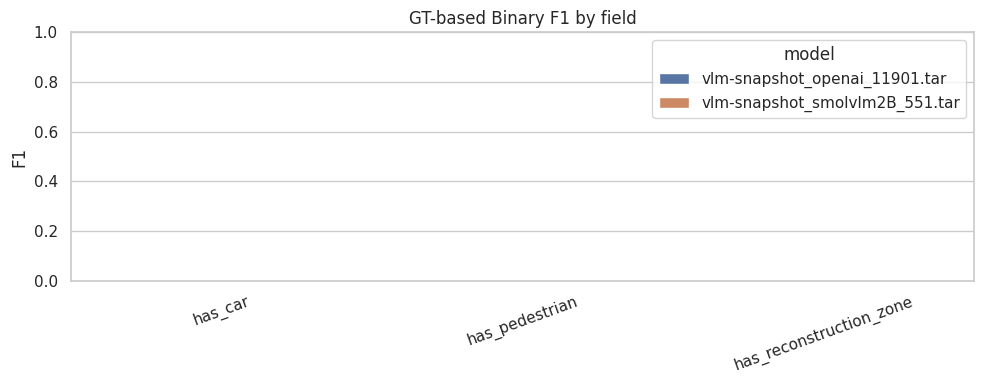

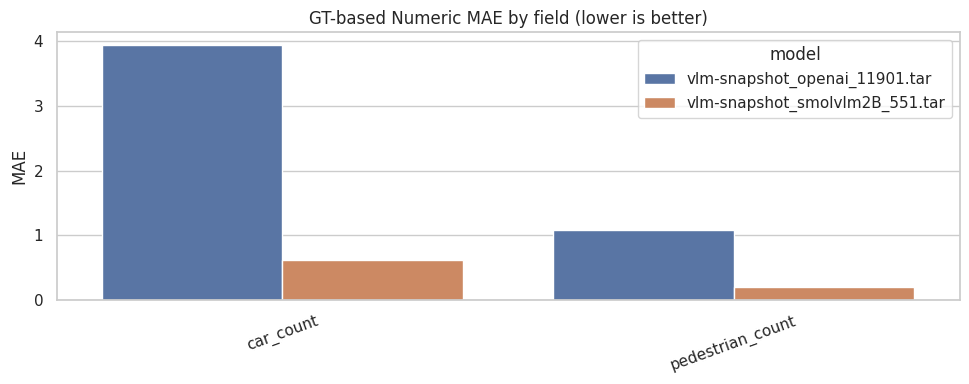

/tmp/ipykernel_11841/933665020.py:41: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


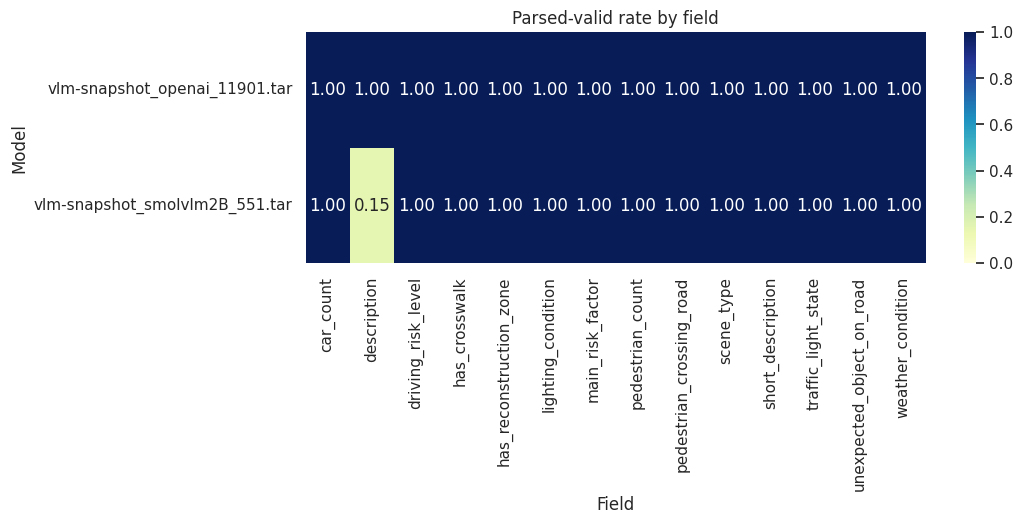

/tmp/ipykernel_11841/933665020.py:41: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


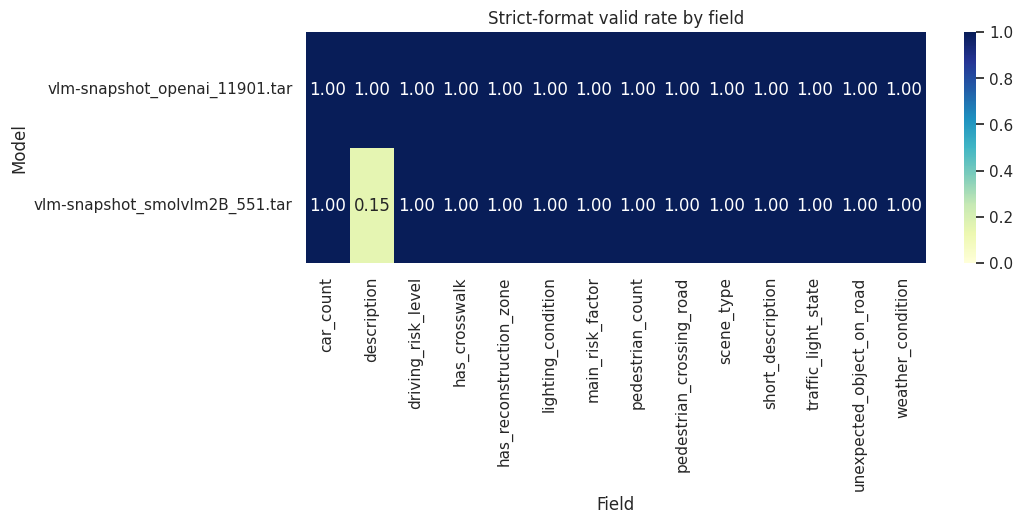

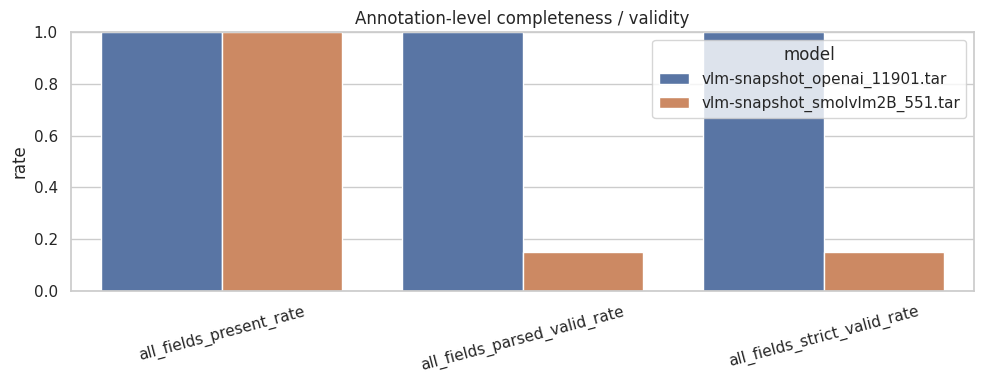

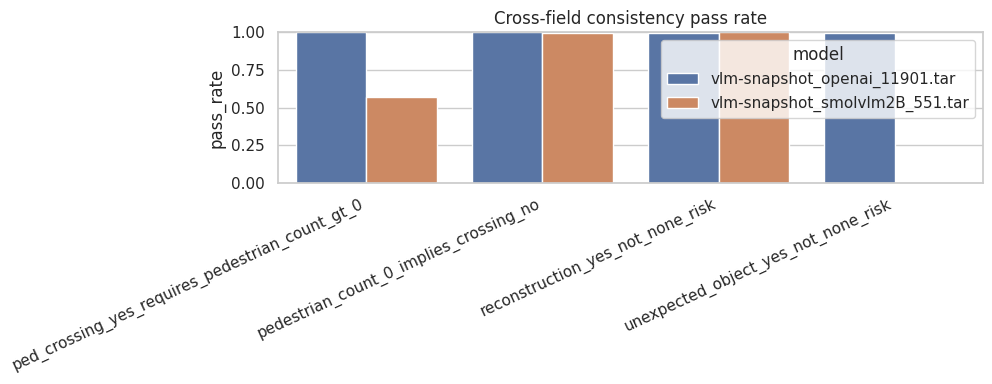

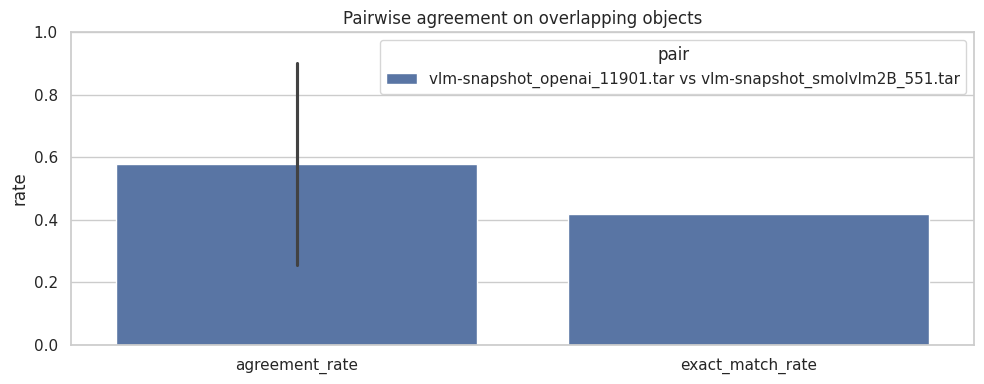

In [7]:
# PLOTS (REPRESENTATIVE SLICES)
def plot_gt_binary_f1(binary_df):
    if binary_df.empty:
        print("No GT binary metrics to plot.")
        return
    plt.figure(figsize=(10, 4))
    sns.barplot(data=binary_df, x="field", y="f1", hue="model")
    plt.ylim(0, 1)
    plt.title("GT-based Binary F1 by field")
    plt.xlabel("")
    plt.ylabel("F1")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()


def plot_gt_numeric_mae(numeric_df):
    if numeric_df.empty:
        print("No GT numeric metrics to plot.")
        return
    plt.figure(figsize=(10, 4))
    sns.barplot(data=numeric_df, x="field", y="mae", hue="model")
    plt.title("GT-based Numeric MAE by field (lower is better)")
    plt.xlabel("")
    plt.ylabel("MAE")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()


def plot_compliance_heatmap(field_df, value_col, title):
    if field_df.empty:
        print(f"No data for {title}.")
        return
    pivot = field_df.pivot_table(index="model", columns="field", values=value_col, aggfunc="mean").fillna(0.0)
    plt.figure(figsize=(max(10, 0.7 * len(pivot.columns)), max(3, 0.7 * len(pivot.index))))
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0, vmax=1)
    plt.title(title)
    plt.xlabel("Field")
    plt.ylabel("Model")
    plt.tight_layout()
    plt.show()


def plot_completeness(completeness_df):
    if completeness_df.empty:
        print("No completeness data.")
        return
    df = completeness_df.sort_values("model").copy()
    plot_df = df.melt(
        id_vars=["model"],
        value_vars=["all_fields_present_rate", "all_fields_parsed_valid_rate", "all_fields_strict_valid_rate"],
        var_name="metric",
        value_name="value",
    )
    plt.figure(figsize=(10, 4))
    sns.barplot(data=plot_df, x="metric", y="value", hue="model")
    plt.ylim(0, 1)
    plt.title("Annotation-level completeness / validity")
    plt.xlabel("")
    plt.ylabel("rate")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()


def plot_consistency(consistency_df):
    if consistency_df.empty:
        print("No consistency data.")
        return
    df = consistency_df.copy()
    plt.figure(figsize=(10, 4))
    sns.barplot(data=df, x="rule", y="pass_rate", hue="model")
    plt.ylim(0, 1)
    plt.title("Cross-field consistency pass rate")
    plt.xlabel("")
    plt.ylabel("pass_rate")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()


def plot_pairwise(pairwise_df):
    if pairwise_df.empty:
        print("No pairwise overlap data.")
        return
    part = pairwise_df[pairwise_df["metric"].isin(["agreement_rate", "exact_match_rate"])].copy()
    if part.empty:
        print("No agreement-style pairwise metrics.")
        return
    part["pair"] = part["model_a"] + " vs " + part["model_b"]
    plt.figure(figsize=(10, 4))
    sns.barplot(data=part, x="metric", y="value", hue="pair")
    plt.ylim(0, 1)
    plt.title("Pairwise agreement on overlapping objects")
    plt.xlabel("")
    plt.ylabel("rate")
    plt.tight_layout()
    plt.show()


plot_gt_binary_f1(gt_binary_summary_df)
plot_gt_numeric_mae(gt_numeric_summary_df)
plot_compliance_heatmap(field_compliance_df, "parsed_valid_rate", "Parsed-valid rate by field")
plot_compliance_heatmap(field_compliance_df, "strict_valid_rate", "Strict-format valid rate by field")
plot_completeness(annotation_completeness_df)
plot_consistency(consistency_by_rule_df)
plot_pairwise(pairwise_agreement_df)


In [8]:
# OPTIONAL DEBUG: leakage + hard disagreements
print("GT reason:", gt_reason)
if "reference snapshot" in str(gt_reason).lower():
    print("WARNING: Reference-snapshot GT mode is active.")
    print("Metrics for the reference model are expected to be near-perfect by construction.")

if not task_metrics_long_df.empty:
    num_part = task_metrics_long_df[task_metrics_long_df["task_type"] == "number"].copy()
    if not num_part.empty:
        num_part["y_pred_effective"] = num_part["y_pred"].apply(lambda x: 0 if pd.isna(x) else int(x))
        num_part["abs_error"] = (num_part["y_true"] - num_part["y_pred_effective"]).abs()
        for (model, field), grp in num_part.groupby(["model", "field"], sort=False):
            print()
            print(f"=== {model} | {field} | top-10 absolute errors ===")
            display(grp.sort_values("abs_error", ascending=False).head(10)[["object_id", "y_true", "y_pred", "valid", "abs_error"]])

if not pairwise_agreement_df.empty:
    print()
    print("Pairwise disagreement indicators:")
    display(pairwise_agreement_df.sort_values(["model_a", "model_b", "response_type", "metric"]).reset_index(drop=True))


GT reason: nuImages via object_id mapping (snapshot/csv/storage-api), matched_rows=11905

=== vlm-snapshot_openai_11901.tar | car_count | top-10 absolute errors ===


,object_id,y_true,y_pred,valid,abs_error
40305,7013917d7b8ad1c12556dfaa3770f901,0,35.0,True,35
50855,8dd16e6ac8c7c032c2d950209ef874cc,0,31.0,True,31
55790,c6c8e236c9eaa32311645b73c1047399,0,25.0,True,25
56300,ce7a14e1eb32e61b71141a793e7cfaa9,0,24.0,True,24
26700,49e4e95651b99c9907bc97c87053cc95,0,24.0,True,24
58700,f2fe14d6f8918c9a1c7d6f1b879d2bfd,0,24.0,True,24
14505,28bf82cdad08e84558d1b518307dde52,0,24.0,True,24
53335,a0b20aaf1160286599638af150f0c31b,0,23.0,True,23
555,014580ad9c3f62dac8208443348582dc,0,23.0,True,23
52185,91bc53e61e24cfa2e9a2ff066ce41277,0,23.0,True,23



=== vlm-snapshot_openai_11901.tar | pedestrian_count | top-10 absolute errors ===


,object_id,y_true,y_pred,valid,abs_error
50911,8dfbf9b9f067363320486bebdc8ff147,0,24.0,True,24
12016,21725ae709bb426a9508d808ed1fdb48,0,22.0,True,22
38656,6b77eb4d3710a16bcbbc6c0e8f06d4e9,0,20.0,True,20
29916,5294ce642b51faa3b70d96123046460c,0,20.0,True,20
5151,0df2458a9a2f69c550ba4b5731df0668,0,20.0,True,20
45111,7e3571481a04c5880895d2b83388909f,0,18.0,True,18
4436,0be046e9e16b11b79ce5a9ae619ecde4,0,18.0,True,18
52476,95b9f25b429afbe0c5b471605994d53c,0,18.0,True,18
47571,855543496d6b7fc9882453a244383f83,0,18.0,True,18
32226,597ba60a3319732bdd0b6aca09958503,0,18.0,True,18



=== vlm-snapshot_smolvlm2B_551.tar | car_count | top-10 absolute errors ===


,object_id,y_true,y_pred,valid,abs_error
61020,03c88db62380ffd902d973663cd7cf6d,0,10.0,True,10
61355,04ae4887740824bfab56b7f2a048a2f2,0,10.0,True,10
62070,06baa695f7427908887b9b4c386fc12e,0,10.0,True,10
59925,00f29c0a6206cf0706a0b1e0133ce933,0,10.0,True,10
61885,061bbca80b50a07c010f1f8e85b60202,0,10.0,True,10
60140,016721c43b4b997efaab729cda658cf2,0,10.0,True,10
60155,01705a5a4f7f61f7fddf37b6eee3a88b,0,10.0,True,10
60240,01a030570bacef7131378f4882344799,0,10.0,True,10
61630,056574ced4852623b62b85202f76699e,0,10.0,True,10
59590,0011bf4bc707bff752ee5b8ed559d956,0,10.0,True,10



=== vlm-snapshot_smolvlm2B_551.tar | pedestrian_count | top-10 absolute errors ===


,object_id,y_true,y_pred,valid,abs_error
61716,05aa9037cd1acdf3547d355373562945,0,11.0,True,11
59551,000584a41705092c6aad79a63c028a96,0,10.0,True,10
61136,040cf2375dfdbaf7a93b15292520a267,0,10.0,True,10
61671,05787e7fc2dfbe067c7d8d651c3dd2bc,0,5.0,True,5
61431,04e014d102e98a10f463213a52c827d0,0,5.0,True,5
60866,03528bf1109ffc8064ed72be546e22c9,0,4.0,True,4
60526,026a15ba362c668153a274c866a21d39,0,4.0,True,4
60741,02fce5809c74a6d72ea89dc7921eb280,0,4.0,True,4
59886,00d6607d16735d67a9d52ea82d0a38f6,0,3.0,True,3
61766,05be093e7151b033494b617fa7725d84,0,3.0,True,3



Pairwise disagreement indicators:


,model_a,model_b,response_type,metric,value,samples
0,vlm-snapshot_openai_11901.tar,vlm-snapshot_smolvlm2B_551.tar,category,agreement_rate,0.255210,2735
1,vlm-snapshot_openai_11901.tar,vlm-snapshot_smolvlm2B_551.tar,number,exact_match_rate,0.419798,1091
2,vlm-snapshot_openai_11901.tar,vlm-snapshot_smolvlm2B_551.tar,number,mae_between_models,2.194317,1091
3,vlm-snapshot_openai_11901.tar,vlm-snapshot_smolvlm2B_551.tar,yes_no,agreement_rate,0.901280,2188
